In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
df = pd.read_csv('../course_data/DATA/mouse_viral_study.csv')

In [33]:
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


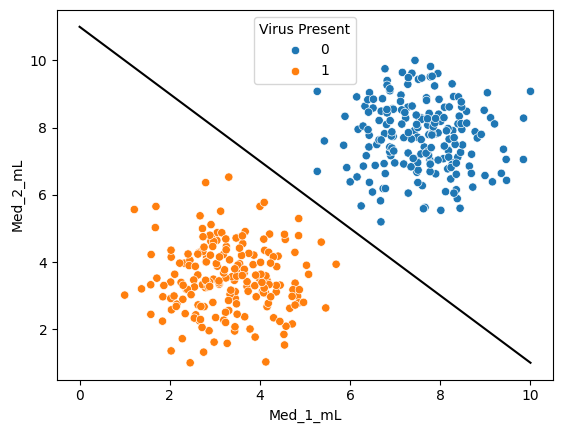

In [34]:
sns.scatterplot(x='Med_1_mL', y='Med_2_mL', hue='Virus Present', data=df)

# Изменяем диапазон x, чтобы он покрывал всю ось (от 0 до 10 или 11)
x = np.linspace(0, 10, 100) 

# Те же коэффициенты (уравнение прямой: y = mx + b)
m = -1
b = 11
y = m * x + b

plt.plot(x, y, 'black')

# Опционально: чтобы график не "улетал" вниз, можно ограничить оси
# plt.ylim(0, 12) 
# plt.xlim(0, 11)

In [45]:
from sklearn.svm import SVC

In [46]:
y = df['Virus Present']
X = df.drop('Virus Present', axis=1)

In [47]:
model = SVC(kernel='linear', C=1000)

In [11]:
model.fit(X, y)

SVC(C=1000, kernel='linear')

In [12]:
hasattr(model, "support_vectors_")

True

In [13]:
# CODE SOURCE IS DIRECTLY FROM DOCUMENTATION
# https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def plot_svm_boundary(model,X,y):
    
    X = X.values
    y = y.values
    
    # Scatter Plot
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30,cmap='seismic')

    
    # plot the decision function
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # plot support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')
    plt.show()

/home/andrew/codding/python/DS_ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


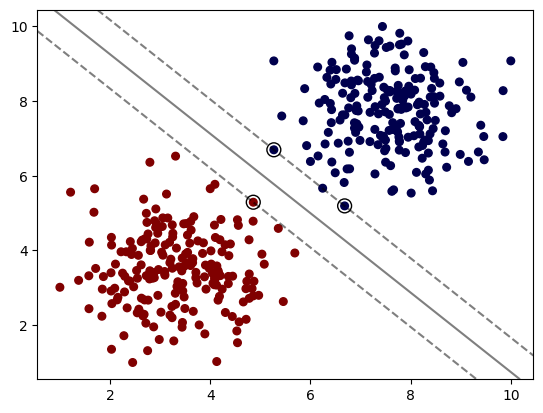

In [14]:
plot_svm_boundary(model,X,y)